In [ ]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [ ]:
DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train.hdf5"

In [ ]:
import h5py
import jax.numpy as jnp

sample_idx = 0
bc_sample = 0.0 # From the paper: u(x) = 0 on the boundary

with h5py.File(FILE_PATH, 'r') as f:
    # 1. Print full dataset shapes to understand the tensor structure
    print("--- Full Dataset Shapes ---")
    print(f"nu shape:         {f['nu'].shape}")
    print(f"tensor shape:     {f['tensor'].shape}")
    print(f"x-coordinate:     {f['x-coordinate'].shape}")
    print(f"y-coordinate:     {f['y-coordinate'].shape}\n")
    
    # 2. Extract Coordinates directly from the dataset
    x_coords = jnp.array(f['x-coordinate'][:])
    y_coords = jnp.array(f['y-coordinate'][:])
    
    # 3. Extract Sample 0 
    a_sample = jnp.array(f['nu'][sample_idx])
    u_raw = jnp.array(f['tensor'][sample_idx])
    
    print(f"--- Sample {sample_idx} ---")
    print(f"Extracted 'a' (nu) shape: {a_sample.shape}")
    print(f"Extracted 'u_raw' (tensor) shape: {u_raw.shape}")

In [ ]:
import h5py
sample_idx = 0
bc_sample = 0.0 # From the paper: u(x) = 0 on the boundary

with h5py.File(FILE_PATH, 'r') as f:
    # Extract exact coordinates
    x_coords = np.array(f['x-coordinate'][:])
    y_coords = np.array(f['y-coordinate'][:])
    
    # Extract Sample 0
    a_sample = jnp.array(f['nu'][sample_idx])
    u_raw = jnp.array(f['tensor'][sample_idx])

# Squeeze out the extra dimension: (1, 128, 128) -> (128, 128)
u_sample = u_raw.squeeze()

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Solution 'u' Shape: {u_flat.shape}")
print(f"Boundary Condition 'bc': {bc_sample:.4f}")

In [ ]:
# Note: cell-centered grid rather than a node-centered grid
nx = len(x_coords) # 128
ny = len(y_coords) # 128
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

# Dynamically find the domain boundaries from the coordinates
x_l, x_u = float(np.min(x_coords)), float(np.max(x_coords)) # 0.00390625, 0.99609375
y_l, y_u = float(np.min(y_coords)), float(np.max(y_coords)) # 0.00390625, 0.99609375

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

print(f"Total grid points: {x.shape[0]}")
print(f"Boundary points extracted: {x_bc.shape[0]}")

In [ ]:
epochs = 1000
M = 512 
hidden_layers = [256, 256, 256, 256] 

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(0.5), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h)
            
        u_pred = nn.Dense(1, use_bias=False)(h)
        return u_pred

model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [ ]:
optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

# VMAP the forward pass
u_pred_vmap = vmap(model.apply, in_axes=(None, 0, 0))

def compute_data_loss(params, x_batch, y_batch, u_batch):
    # Predict u directly from the neural network
    u_pred = u_pred_vmap(params, x_batch, y_batch)
    
    # Calculate pure MSE against the simulation data
    loss = jnp.mean((u_pred - u_batch) ** 2)
    return loss

loss_grad_fn = jax.jit(value_and_grad(compute_data_loss, argnums=0))

@jax.jit
def update_network(params, opt_state, x_batch, y_batch, u_batch):
    loss, grads = loss_grad_fn(params, x_batch, y_batch, u_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [ ]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 2000 
loss_history = []

for epoch in tqdm(range(epochs), desc="Pure Data-Loss Sanity Check"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss = update_network(
        params, opt_state, x_chunk, y_chunk, u_chunk
    )
    
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        sigma_val = jax.nn.softplus(params['params']['raw_sigma'][0])
        print(f"Epoch {epoch} | Data MSE Loss: {loss:.4e} | Learned Sigma: {sigma_val:.4f}")

In [ ]:
# Predict the full grid directly
u_pred_full = u_pred_vmap(params, x, y)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pure MLP Prediction (Data Loss Only)')

plt.tight_layout()
plt.show()

In [ ]:
import pickle
import numpy as np
from jax.tree_util import tree_map

def save_weights(params, filename="pretrained_helmholtz_mlp.pkl"):
    # Convert JAX DeviceArrays to standard NumPy arrays for safe pickling
    numpy_params = tree_map(lambda x: np.array(x), params)
    with open(filename, 'wb') as f:
        pickle.dump(numpy_params, f)
    print(f"Weights successfully saved to {filename}")

def load_weights(filename="pretrained_helmholtz_mlp.pkl"):
    with open(filename, 'rb') as f:
        numpy_params = pickle.load(f)
    # Convert back to JAX arrays
    jax_params = tree_map(lambda x: jnp.array(x), numpy_params)
    print(f"Weights successfully loaded from {filename}")
    return jax_params

# Example Usage:
save_weights(params) 
params = load_weights()

In [ ]:
# EXTRACT FROZEN FRONT-END WEIGHTS
frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = params['params'][dense_name]

# Extract and apply the learned sigma to B_matrix_base
learned_raw_sigma = params['params']['raw_sigma'][0]
learned_sigma = jax.nn.softplus(learned_raw_sigma)
print(f"Applying learned bandwidth (sigma = {learned_sigma:.4f}) to the features...")

# DEFINE FROZEN MODEL (NO FINAL LAYER)
class FrozenFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(1), (1,)) 
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size)(h)
            h = nn.tanh(h)
            
        return h # Outputs shape (256,)

model_frozen = FrozenFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

In [ ]:
beta = 10.0 # From dataset filename 2D_DarcyFlow_beta10.0_Train.hdf5

# Calculate spatial gradients of the field 'a' using central differences
h_x = x_coords[1] - x_coords[0]
h_y = y_coords[1] - y_coords[0]
da_dx, da_dy = jnp.gradient(a_sample, h_x, h_y)

a_x_flat = da_dx.reshape(-1, 1)
a_y_flat = da_dy.reshape(-1, 1)

from scipy.ndimage import gaussian_filter

# 1. Smooth the discontinuous 'a' field
# A sigma of 1.5 to 2.0 pixels turns the jump into a network-friendly ramp
a_sample_np = np.array(a_sample)
a_sample_smoothed = jnp.array(gaussian_filter(a_sample_np, sigma=1.5))

# 2. Calculate spatial gradients on the SMOOTHED field
h_x = x_coords[1] - x_coords[0]
h_y = y_coords[1] - y_coords[0]
da_dx, da_dy = jnp.gradient(a_sample_smoothed, h_x, h_y)

# 3. Flatten for the network
a_flat_smooth = a_sample_smoothed.reshape(-1, 1)
a_x_flat = da_dx.reshape(-1, 1)
a_y_flat = da_dy.reshape(-1, 1)

# 4. Sample randomly from ALL points (No masking needed!)
rng = jax.random.PRNGKey(42)
total_points = x.shape[0]
spatial_batch_size = 5000 

rng, shuffle_key = jax.random.split(rng)
batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)

x_sampled = x[batch_idx]
y_sampled = y[batch_idx]
a_sampled = a_flat_smooth[batch_idx]  # Use the smoothed 'a'
a_x_sampled = a_x_flat[batch_idx]
a_y_sampled = a_y_flat[batch_idx]


# # BUILD THE PHYSICS & BC MATRICES (SAMPLED)
# rng = jax.random.PRNGKey(42)
# total_points = x.shape[0]
# spatial_batch_size = 5000 

# rng, shuffle_key = jax.random.split(rng)
# batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)

# x_sampled = x[batch_idx]
# y_sampled = y[batch_idx]
# a_sampled = a_flat[batch_idx]
# a_x_sampled = a_x_flat[batch_idx]
# a_y_sampled = a_y_flat[batch_idx]

@jax.jit
def compute_A_pde(x_val, y_val, a_val, a_x_val, a_y_val):
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    # First derivatives (needed for Darcy)
    H_x = jax.jacfwd(get_H, argnums=0)(x_val, y_val)
    H_y = jax.jacfwd(get_H, argnums=1)(x_val, y_val)
    
    # Second derivatives
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
    
    H_x = jnp.squeeze(H_x)
    H_y = jnp.squeeze(H_y)
    H_xx = jnp.squeeze(H_xx)
    H_yy = jnp.squeeze(H_yy)
    
    # Darcy Flow PDE Operator: -(a_x * H_x + a_y * H_y + a * (H_xx + H_yy))
    L_H = -(a_x_val * H_x + a_y_val * H_y + a_val * (H_xx + H_yy))
    return L_H

compute_A_pde_vmap = jax.jit(vmap(compute_A_pde))

print(f"Compiling and evaluating PDE matrices for {spatial_batch_size} sampled points...")
chunk_size = 1000
A_pde_chunks = []

for i in range(0, spatial_batch_size, chunk_size):
    A_chunk = compute_A_pde_vmap(
        x_sampled[i:i + chunk_size], 
        y_sampled[i:i + chunk_size], 
        a_sampled[i:i + chunk_size],
        a_x_sampled[i:i + chunk_size],
        a_y_sampled[i:i + chunk_size]
    )
    A_pde_chunks.append(A_chunk)

A_pde = jnp.vstack(A_pde_chunks)
b_pde = jnp.ones((spatial_batch_size, 1)) * beta

print("Compiling and evaluating BC matrices...")
A_bc = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x_bc, y_bc)
b_bc = bc_val_array.reshape(-1, 1)

print(f"Finished building matrices! A_pde shape: {A_pde.shape}, A_bc shape: {A_bc.shape}")

Compiling and evaluating PDE matrices for 5000 sampled points...
Compiling and evaluating BC matrices...
Finished building matrices! A_pde shape: (5000, 256), A_bc shape: (508, 256)


In [56]:
lambda_bcs = [1e2, 1e3, 1e4, 1e6, 1e8, 1e9, 1e10, 1e11, 1e12]
tik_regs = [1e-3, 1e-4, 1e-5, 1e-6]

best_mse = float('inf')
best_params_combo = {}
best_u_pred = None

I = jnp.eye(A_pde.shape[1]) 

print("\nStarting Sweep:")
print("-" * 80)

all_sweep_preds = {}

for lmbda in lambda_bcs:
    for tik in tik_regs:
        sqrt_lambda = jnp.sqrt(lmbda)
        A = jnp.vstack([A_pde, sqrt_lambda * A_bc])
        B = jnp.vstack([b_pde, sqrt_lambda * b_bc])
        
        # Least Squares Solve
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B)
        
        # Calculate Unscaled PDE Loss (A_pde @ w - b_pde)
        pde_residual = A_pde @ w - b_pde
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        
        # Calculate Unscaled BC Loss (A_bc @ w - b_bc)
        bc_residual = A_bc @ w - b_bc
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Calculate Unscaled Data MSE (Full Grid)
        H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)
        u_pred_sweep = H_full @ w
        mse = jnp.mean((u_pred_sweep - u_flat) ** 2)
        
        print(f"Lam: {lmbda:<7.1e} | Tik: {tik:<7.1e} | MSE: {mse:.2e} | PDE: {loss_pde_unscaled:.2e} | BC: {loss_bc_unscaled:.2e}")
        
        all_sweep_preds[(lmbda, tik)] = u_pred_sweep
        
        # Track the best performing combination
        if mse < best_mse:
            best_mse = mse
            best_params_combo = {'lambda': lmbda, 'tik_reg': tik, 'w': w}
            best_u_pred = u_pred_sweep

print("-" * 80)
print(f"BEST FOUND: Lambda = {best_params_combo['lambda']}, TikReg = {best_params_combo['tik_reg']}")
print(f"BEST MSE  = {best_mse:.4e}")


Starting Sweep:
--------------------------------------------------------------------------------
Lam: 1.0e+02 | Tik: 1.0e-03 | MSE: 3.82e+00 | PDE: 5.98e+01 | BC: 3.46e-02
Lam: 1.0e+02 | Tik: 1.0e-04 | MSE: 3.82e+00 | PDE: 5.98e+01 | BC: 3.46e-02
Lam: 1.0e+02 | Tik: 1.0e-05 | MSE: 3.82e+00 | PDE: 5.98e+01 | BC: 3.46e-02
Lam: 1.0e+02 | Tik: 1.0e-06 | MSE: 3.82e+00 | PDE: 5.98e+01 | BC: 3.46e-02
Lam: 1.0e+03 | Tik: 1.0e-03 | MSE: 4.23e+00 | PDE: 6.07e+01 | BC: 1.62e-02
Lam: 1.0e+03 | Tik: 1.0e-04 | MSE: 4.23e+00 | PDE: 6.07e+01 | BC: 1.62e-02
Lam: 1.0e+03 | Tik: 1.0e-05 | MSE: 4.23e+00 | PDE: 6.07e+01 | BC: 1.62e-02
Lam: 1.0e+03 | Tik: 1.0e-06 | MSE: 4.23e+00 | PDE: 6.07e+01 | BC: 1.62e-02
Lam: 1.0e+04 | Tik: 1.0e-03 | MSE: 5.03e+00 | PDE: 6.49e+01 | BC: 2.01e-03
Lam: 1.0e+04 | Tik: 1.0e-04 | MSE: 5.03e+00 | PDE: 6.49e+01 | BC: 2.01e-03
Lam: 1.0e+04 | Tik: 1.0e-05 | MSE: 5.03e+00 | PDE: 6.49e+01 | BC: 2.01e-03
Lam: 1.0e+04 | Tik: 1.0e-06 | MSE: 5.03e+00 | PDE: 6.49e+01 | BC: 2.01e-03
La

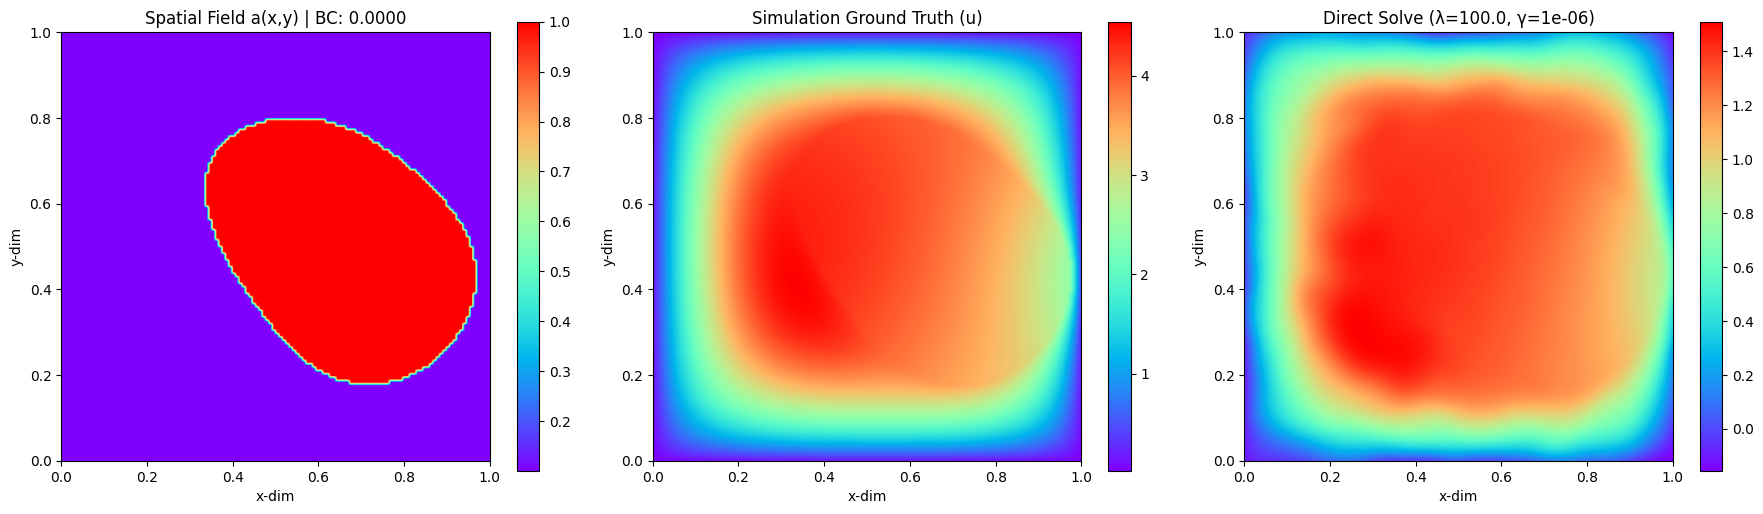

In [57]:
# ==========================================
# E. VISUALIZE BEST SWEEP RESULT
# ==========================================
target_lambda = best_params_combo['lambda']
target_tik = best_params_combo['tik_reg']
target_u_pred = all_sweep_preds[(target_lambda, target_tik)]

a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
# u_pred_plot = target_u_pred.reshape(nx, ny).T
u_pred_plot = best_u_pred.reshape(nx,  ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]
 
mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
title_str = f'Direct Solve (λ={target_lambda}, γ={target_tik})'
axes[2].set_title(title_str, fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

--- RAW DATASET PHYSICS CHECK ---
Expected RHS (beta): 10.0
Actual median LHS:   9.9863
Actual mean LHS:     9.9880


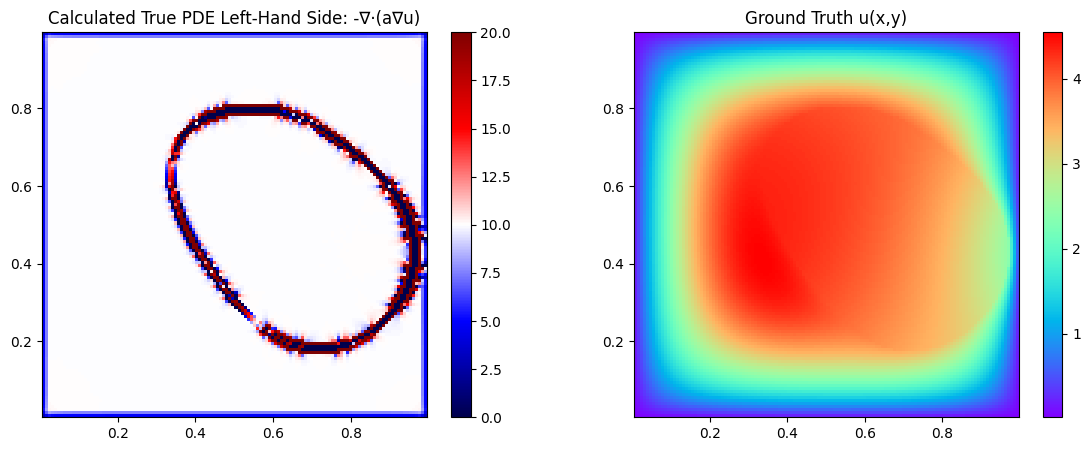

In [58]:
import matplotlib.pyplot as plt
from jax import numpy as jnp

# 1. Spatial steps
h_x = x_coords[1] - x_coords[0]
h_y = y_coords[1] - y_coords[0]

# 2. Compute first derivatives: ∇u
u_x, u_y = jnp.gradient(u_sample, h_x, h_y)

# 3. Compute fluxes: a * ∇u
flux_x = a_sample * u_x
flux_y = a_sample * u_y

# 4. Compute divergence: ∇ · (a * ∇u)
flux_xx, _ = jnp.gradient(flux_x, h_x, h_y)
_, flux_yy = jnp.gradient(flux_y, h_x, h_y)

# The full Darcy Left-Hand Side
pde_lhs = -(flux_xx + flux_yy)

# 5. Mask out the boundaries to ignore the step-function boundary spikes
# We only want to look at the smooth interior physics
interior_pde = pde_lhs[10:-10, 10:-10]

print("--- RAW DATASET PHYSICS CHECK ---")
print(f"Expected RHS (beta): {beta}")
print(f"Actual median LHS:   {jnp.median(interior_pde):.4f}")
print(f"Actual mean LHS:     {jnp.mean(interior_pde):.4f}")

# Plotting to visually inspect the physics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ext = [float(x_coords.min()), float(x_coords.max()), float(y_coords.min()), float(y_coords.max())]

# Limit the color scale to easily spot the expected beta value of 10.0
mesh1 = axes[0].imshow(pde_lhs.T, origin='lower', cmap='seismic', vmin=0, vmax=20, extent=ext)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title('Calculated True PDE Left-Hand Side: -∇·(a∇u)')

mesh2 = axes[1].imshow(u_sample.T, origin='lower', cmap='rainbow', extent=ext)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Ground Truth u(x,y)')

plt.show()

--- NUMERICAL PROOF ---
Max value of original 'a': 1.0000
Min value of original 'a': 0.1000
------------------------------
Max gradient spike |∇a|:   81.4587
Median gradient (inside):  0.0000


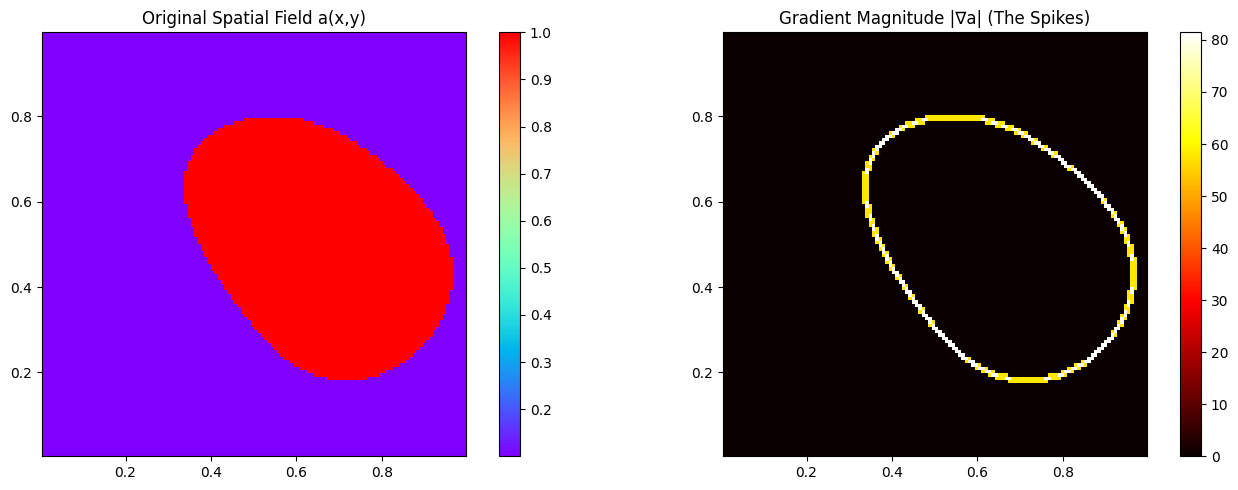

In [54]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# 1. Calculate grid step sizes
h_x = x_coords[1] - x_coords[0]
h_y = y_coords[1] - y_coords[0]

# 2. Compute spatial gradients using central difference
da_dx, da_dy = jnp.gradient(a_sample, h_x, h_y)

# 3. Calculate the magnitude of the gradient vector
grad_magnitude = jnp.sqrt(da_dx**2 + da_dy**2)

# 4. Print the numerical proof
print("--- NUMERICAL PROOF ---")
print(f"Max value of original 'a': {jnp.max(a_sample):.4f}")
print(f"Min value of original 'a': {jnp.min(a_sample):.4f}")
print("-" * 30)
print(f"Max gradient spike |∇a|:   {jnp.max(grad_magnitude):.4f}")
print(f"Median gradient (inside):  {jnp.median(grad_magnitude):.4f}")

# 5. Visual Proof
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ext = [float(x_coords.min()), float(x_coords.max()), float(y_coords.min()), float(y_coords.max())]

mesh1 = axes[0].imshow(a_sample.T, origin='lower', cmap='rainbow', extent=ext)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title('Original Spatial Field a(x,y)')

# Use 'hot' colormap to highlight the spikes
mesh2 = axes[1].imshow(grad_magnitude.T, origin='lower', cmap='hot', extent=ext)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Gradient Magnitude |∇a| (The Spikes)')

plt.tight_layout()
plt.show()

In [ ]:
import jax.numpy as jnp

# 1. Extract the final layer weights the MLP learned during pure data training
w_learned = params['params']['Dense_4']['kernel']

# 2. Check the scale of our PDE matrix
mean_A = jnp.mean(jnp.abs(A_pde))
max_A = jnp.max(jnp.abs(A_pde))

# 3. Calculate the PDE loss using the network's OWN learned weights
pde_eval = A_pde @ w_learned
pde_residual = pde_eval - b_pde
mse_pde_learned = jnp.mean(pde_residual ** 2)

print("--- THE DERIVATIVE EXPLOSION CHECK ---")
print(f"Mean absolute value in A_pde: {mean_A:.4f}")
print(f"Max absolute value in A_pde:  {max_A:.4f}")
print("-" * 40)
print(f"PDE Loss using the network's OWN learned weights: {mse_pde_learned:.4e}")

In [ ]:
# # ==========================================
# # STATIC SCALAR WEIGHTING 
# # ==========================================
# full_params = load_weights("pretrained_helmholtz_mlp.pkl")

# frozen_params = {'params': {}}
# frozen_params['params']['raw_sigma'] = full_params['params']['raw_sigma']
# for i in range(len(hidden_layers)):
#     dense_name = f'Dense_{i}'
#     frozen_params['params'][dense_name] = full_params['params'][dense_name]

# matrix_lmbda = 1e11
# sqrt_matrix_lmbda = jnp.sqrt(matrix_lmbda)
# tik = 1e-4

# pde_loss_weight = 1e-5
# bc_loss_weight = 1e4
# data_loss_weight = 0

# @jax.jit
# def diff_physics_step_discrete(current_frozen_params, x_full, y_full, a_full, x_bc, y_bc, bc_val_arr, u_full):
#     def compute_all_losses(params):
#         def get_H(x_in, y_in):
#             return model_frozen.apply(params, x_in, y_in) 
            
#         def compute_pde_row(x_val, y_val, a_val):
#             H = get_H(x_val, y_val)
#             H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
#             H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
#             Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
#             return -Laplacian_H - omega_sq * a_val * H
            
#         x_interior = x_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
#         y_interior = y_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
#         a_interior = a_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
        
#         A_pde = vmap(compute_pde_row)(x_interior, y_interior, a_interior)
#         b_pde = jnp.zeros((A_pde.shape[0], 1))
        
#         A_bc = jax.vmap(lambda x_in, y_in: model_frozen.apply(params, x_in, y_in))(x_bc, y_bc)
#         b_bc = bc_val_arr.reshape(-1, 1)
        
#         A = jnp.vstack([A_pde, sqrt_matrix_lmbda * A_bc])
#         B = jnp.vstack([b_pde, sqrt_matrix_lmbda * b_bc])
        
#         I = jnp.eye(A.shape[1])
#         A_T_A = A.T @ A
#         A_T_B = A.T @ B
#         w_diff = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
        
#         pde_residual = A_pde @ w_diff - b_pde
#         bc_residual = A_bc @ w_diff - b_bc
        
#         loss_pde_unscaled = jnp.mean(pde_residual ** 2)
#         loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
#         H_flat = jax.vmap(lambda x_in, y_in: model_frozen.apply(params, x_in, y_in))(x_full, y_full)
#         u_pred_flat = H_flat @ w_diff
#         mse = jnp.mean((u_pred_flat - u_full) ** 2)
        
#         # Return all three losses so VJP can differentiate them
#         return (loss_pde_unscaled, loss_bc_unscaled, mse)

#     # Run Vector-Jacobian Product expecting 3 loss terms
#     loss_tuple, vjp_fn = jax.vjp(compute_all_losses, current_frozen_params)
#     l_pde, l_bc, mse = loss_tuple
    
#     # Extract independent pure gradients for PDE, BC, and Data
#     pde_grads = vjp_fn((1.0, 0.0, 0.0))[0]
#     bc_grads = vjp_fn((0.0, 1.0, 0.0))[0]
#     data_grads = vjp_fn((0.0, 0.0, 1.0))[0]
    
#     pde_norm = optax.global_norm(pde_grads)
#     bc_norm = optax.global_norm(bc_grads)
#     data_norm = optax.global_norm(data_grads)
    
#     # ----------------------------------------------------
#     # APPLY STATIC WEIGHTS TO THE GRADIENTS
#     # ----------------------------------------------------
#     balanced_pde = jax.tree_util.tree_map(lambda g: g * pde_loss_weight, pde_grads)
#     balanced_bc = jax.tree_util.tree_map(lambda g: g * bc_loss_weight, bc_grads)
#     balanced_data = jax.tree_util.tree_map(lambda g: g * data_loss_weight, data_grads)
    
#     # Construct the final balanced gradient update vector
#     total_grads = jax.tree_util.tree_map(
#         lambda g1, g2, g3: g1 + g2 + g3, 
#         balanced_pde, balanced_bc, balanced_data
#     )
    
#     # Freeze sigma by zeroing out its gradient
#     total_grads['params']['raw_sigma'] = jnp.zeros_like(total_grads['params']['raw_sigma'])
    
#     return l_pde, l_bc, mse, total_grads, pde_norm, bc_norm, data_norm

In [ ]:
# meta_optimizer = optax.adamw(learning_rate=1e-5) 
# meta_opt_state = meta_optimizer.init(frozen_params)

# epochs = 300

# history_pde = []
# history_bc = []
# history_data = []
# history_total = []

# print(f"Starting Balanced Pretrained Physics Loop for {epochs} epochs (DATA LOSS WEIGHT = {data_loss_weight})...")
# for epoch in range(epochs):
    
#     l_pde, l_bc, mse, total_grads, pde_norm, bc_norm, data_norm = diff_physics_step_discrete(
#         frozen_params, x, y, a_flat, x_bc, y_bc, bc_val_array, u_flat
#     )
    
#     updates, meta_opt_state = meta_optimizer.update(total_grads, meta_opt_state, params=frozen_params)
#     frozen_params = optax.apply_updates(frozen_params, updates)
    
#     history_pde.append(float(l_pde))
#     history_bc.append(float(l_bc))
#     history_data.append(float(mse))
#     history_total.append(float(l_pde + l_bc)) 
    
#     if epoch % 50 == 0:
#         print(f"Epoch {epoch:<3} | True Data MSE: {mse:.4e}")
#         print(f"            ├─ Raw Residuals  => PDE: {l_pde:.4e} | BC: {l_bc:.4e}")
#         print(f"            └─ True Grad Norms => PDE: {pde_norm:.3e} | BC: {bc_norm:.3e} | Data: {data_norm:.3e}")

In [ ]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# # 1st Plot: Overall Total Loss
# axes[0].plot(history_total, color='black', linewidth=2)
# axes[0].set_yscale('log')
# axes[0].set_title('Overall Total Loss', fontsize=14)
# axes[0].set_ylabel('Loss (Log Scale)', fontsize=12)
# axes[0].set_xlabel('Epochs', fontsize=12)
# axes[0].grid(True, which="both", ls="-", alpha=0.3)

# # 2nd Plot: PDE Loss
# axes[1].plot(history_pde, color='blue', linewidth=2)
# axes[1].set_yscale('log')
# axes[1].set_title('PDE Loss (Physics Match)', fontsize=14)
# axes[1].set_xlabel('Epochs', fontsize=12)
# axes[1].grid(True, which="both", ls="-", alpha=0.3)

# # 3rd Plot: BC Loss
# axes[2].plot(history_bc, color='green', linewidth=2)
# axes[2].set_yscale('log')
# axes[2].set_title('Boundary Condition (BC) Loss', fontsize=14)
# axes[2].set_xlabel('Epochs', fontsize=12)
# axes[2].grid(True, which="both", ls="-", alpha=0.3)

# # 4th Plot: Data MSE
# axes[3].plot(history_data, color='red', linewidth=2)
# axes[3].set_yscale('log')
# axes[3].set_title('Data MSE (Ground Truth Match)', fontsize=14)
# axes[3].set_xlabel('Epochs', fontsize=12)
# axes[3].grid(True, which="both", ls="-", alpha=0.3)

# plt.tight_layout()
# plt.show()

In [ ]:
# @jax.jit
# def get_discrete_prediction(current_frozen_params, x_full, y_full, a_full, x_bc, y_bc, bc_val_arr):
#     def get_H(x_in, y_in):
#         return model_frozen.apply(current_frozen_params, x_in, y_in) 
        
#     def compute_pde_row(x_val, y_val, a_val):
#         H = get_H(x_val, y_val)
#         H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
#         H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
#         Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
#         return -Laplacian_H - omega_sq * a_val * H
    
#     x_interior = x_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
#     y_interior = y_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
#     a_interior = a_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)

#     # 1. Assemble PDE (Interior Matrix) via Autodiff
#     A_pde = vmap(compute_pde_row)(x_interior, y_interior, a_interior)
#     b_pde = jnp.zeros((A_pde.shape[0], 1))

#     # # 1. Assemble PDE (Interior Matrix) via Autodiff
#     # A_pde = vmap(compute_pde_row)(x_full, y_full, a_full)
#     # b_pde = jnp.zeros((A_pde.shape[0], 1))
    
#     # 2. Assemble BC
#     A_bc = jax.vmap(lambda x_in, y_in: model_frozen.apply(current_frozen_params, x_in, y_in))(x_bc, y_bc)
#     b_bc = bc_val_arr.reshape(-1, 1)
    
#     # 3. Least Squares Solve
#     A = jnp.vstack([A_pde, sqrt_matrix_lmbda * A_bc])
#     B = jnp.vstack([b_pde, sqrt_matrix_lmbda * b_bc])
    
#     I = jnp.eye(A.shape[1])
#     A_T_A = A.T @ A
#     A_T_B = A.T @ B
#     w_final = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
    
#     # 4. Final Output Prediction
#     H_flat = jax.vmap(lambda x_in, y_in: model_frozen.apply(current_frozen_params, x_in, y_in))(x_full, y_full)
#     u_pred_flat = H_flat @ w_final
#     return u_pred_flat, w_final

# # Execute the discrete solve
# u_pred_full, final_w = get_discrete_prediction(frozen_params, x, y, a_flat, x_bc, y_bc, bc_val_array)

# # Calculate final full-grid Data MSE
# final_mse = jnp.mean((u_pred_full - u_flat) ** 2)
# print(f"Final True Full-Grid Data MSE: {final_mse:.4e}")

# # ==========================================
# # VISUALIZATION
# # ==========================================
# a_plot = a_flat.reshape(nx, ny).T
# u_sim_plot = u_flat.reshape(nx, ny).T 
# u_pred_plot = u_pred_full.reshape(nx, ny).T
# error_plot = jnp.abs(u_sim_plot - u_pred_plot)

# fig, axes = plt.subplots(1, 4, figsize=(24, 5))
# ext = [0, 1, 0, 1]

# # Lock the color scale of the prediction to the true simulation scale
# # This prevents matplotlib from auto-scaling and hiding amplitude collapse
# vmin_u = float(jnp.min(u_sim_plot))
# vmax_u = float(jnp.max(u_sim_plot))

# # Plot 1: Medium
# mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
# fig.colorbar(mesh1, ax=axes[0])
# axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')

# # Plot 2: Ground Truth
# mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=vmin_u, vmax=vmax_u)
# fig.colorbar(mesh2, ax=axes[1])
# axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')

# # Plot 3: Network Prediction
# mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=vmin_u, vmax=vmax_u)
# fig.colorbar(mesh3, ax=axes[2])
# axes[2].set_title('Discrete Pseudoinverse Prediction', fontsize='large')

# # Plot 4: Absolute Error
# mesh4 = axes[3].imshow(error_plot, interpolation='bilinear', origin='lower', cmap='Reds', extent=ext, aspect=1.)
# fig.colorbar(mesh4, ax=axes[3])
# axes[3].set_title('Absolute Point-wise Error', fontsize='large')

# for ax in axes:
#     ax.set_xlabel('x-dim')
#     ax.set_ylabel('y-dim')

# plt.tight_layout()
# plt.show()

In [ ]:
# import h5py
# import numpy as np
# import matplotlib.pyplot as plt
# import jax.scipy.signal
# from jax import numpy as jnp
# from pathlib import Path

# # ==========================================
# # 1. SETUP & DATA LOADING
# # ==========================================
# DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
# FILE_PATH = DATA_DIR / "Helmholtz.h5"

# sample_idx = 0
# sample_key = f"Sample_{sample_idx}"

# print(f"Extracting raw data for {sample_key}...")
# with h5py.File(FILE_PATH, 'r') as f:
#     a_grid = jnp.array(f[sample_key]['a'][:])
#     u_grid = jnp.array(f[sample_key]['u'][:])

# # ==========================================
# # 2. DISCRETE PHYSICS PARAMETERS
# # ==========================================
# # The spatial step size
# h = 1.0 / 128.0

# # The TRUE dataset constant we discovered
# omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

# # The standard 5-point discrete Laplacian stencil
# laplacian_kernel = jnp.array([
#     [0.0,  1.0, 0.0],
#     [1.0, -4.0, 1.0],
#     [0.0,  1.0, 0.0]
# ]) / (h ** 2)

# # ==========================================
# # 3. CALCULATE THE PDE RESIDUAL
# # ==========================================
# # Apply the convolution to find the discrete Laplacian
# # mode='valid' strips the 1-pixel outer border to prevent edge-wrapping artifacts
# laplacian_u = jax.scipy.signal.convolve2d(u_grid, laplacian_kernel, mode='valid')

# # Slice the 'a' and 'u' grids to match the 126x126 'valid' interior
# a_valid = a_grid[1:-1, 1:-1]
# u_valid = u_grid[1:-1, 1:-1]

# # The Helmholtz Residual: -Laplacian(u) - omega^2 * a * u = 0
# reaction_term = omega_sq * a_valid * u_valid
# pde_residual = -laplacian_u - reaction_term

# # ==========================================
# # 4. METRICS & VALIDATION
# # ==========================================
# # Calculate how close the residual is to absolute zero
# mae = jnp.mean(jnp.abs(pde_residual))
# mse = jnp.mean(pde_residual ** 2)
# max_error = jnp.max(jnp.abs(pde_residual))

# print("-" * 50)
# print(f"RAW SIMULATION PDE RESIDUAL METRICS")
# print(f"Using omega_sq = {omega_sq:.4f}")
# print("-" * 50)
# print(f"Mean Absolute Error (MAE): {mae:.4e}")
# print(f"Mean Squared Error (MSE):  {mse:.4e}")
# print(f"Maximum Point Error:       {max_error:.4e}")
# print("-" * 50)

# # ==========================================
# # 5. VISUALIZATION
# # ==========================================
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# ext = [0, 1, 0, 1]

# # Plot Spatial Field
# mesh1 = axes[0].imshow(a_grid.T, origin='lower', cmap='rainbow', extent=ext)
# fig.colorbar(mesh1, ax=axes[0])
# axes[0].set_title('Spatial Field a(x,y)')

# # Plot Ground Truth u
# mesh2 = axes[1].imshow(u_grid.T, origin='lower', cmap='rainbow', extent=ext)
# fig.colorbar(mesh2, ax=axes[1])
# axes[1].set_title('Simulation Ground Truth (u)')

# # Plot the PDE Residual
# # Using a diverging colormap (seismic) centered at 0 to easily spot positive/negative errors
# vmax = float(jnp.max(jnp.abs(pde_residual)))
# mesh3 = axes[2].imshow(pde_residual.T, origin='lower', cmap='seismic', extent=ext, vmin=-vmax, vmax=vmax)
# fig.colorbar(mesh3, ax=axes[2])
# axes[2].set_title('Raw Data PDE Residual (Error)')

# plt.tight_layout()
# plt.show()